PROJECT: TITANIC CAPSTONE GUIDE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

STAGE 1: LOAD AND CLEAN

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [3]:
print("Shape:", df.shape)

Shape: (891, 12)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


Drop duplicates and the ID column (not useful for prediction)

In [7]:
df = df.drop_duplicates()
df = df.drop(columns=["Cabin"])

In [8]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

In [9]:
# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [10]:
# Create FamilySize
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [11]:
# Create IsAlone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [12]:
print("\nMissing values after cleaning:", df.isnull().sum().sum())


Missing values after cleaning: 0


STAGE 2: EXPLORE AND DESCRIBE

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
 11  FamilySize   891 non-null    int64  
 12  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 90.6 KB
None


In [14]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  FamilySize     IsAlone  
count  891.000000  891.000000  891.000000  891.000000  
mean     0.381594   32.204208    1.904602    0.602694  
std      0.806057   49.693429    1.613459    0.489615  
min      0.000000    0.000000    1.000000    0.000000  
25%      0.000000    7.910400    1.000000    0.000000  
50%      0.000000   14.454200    

In [15]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [16]:
print(df["Sex"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


In [17]:
# Survival rate
print(df["Survived"].mean())

0.3838383838383838


In [18]:
# Survival rate by gender
print(df.groupby("Sex")["Survived"].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [19]:
# Survival rate by passenger class
print(df.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


This shows a strong relationship between sex, passenger class, and survival

STAGE 3: VISUALIZE

Survival by gender

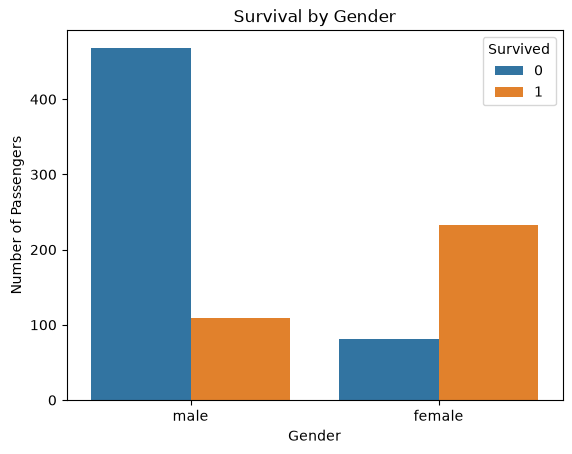

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.savefig("chart1_survival_by_gender.png")
plt.show()

Female passengers had a substantially higher survival rate than male passengers in the dataset

Survival by passenger class

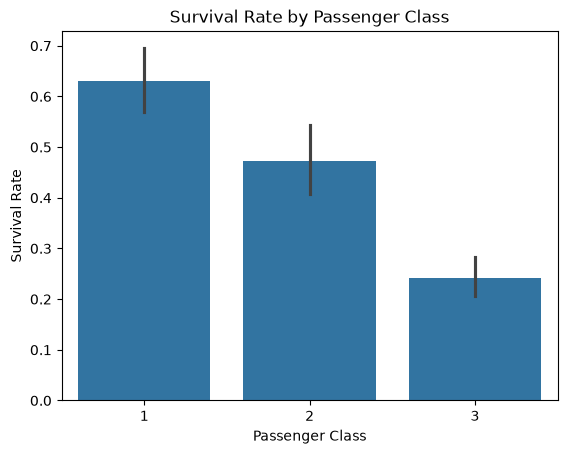

In [21]:
sns.barplot(data=df, x="Pclass", y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.savefig("chart2_survival_rate_by_passenger_class.png")
plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest

Age distribution

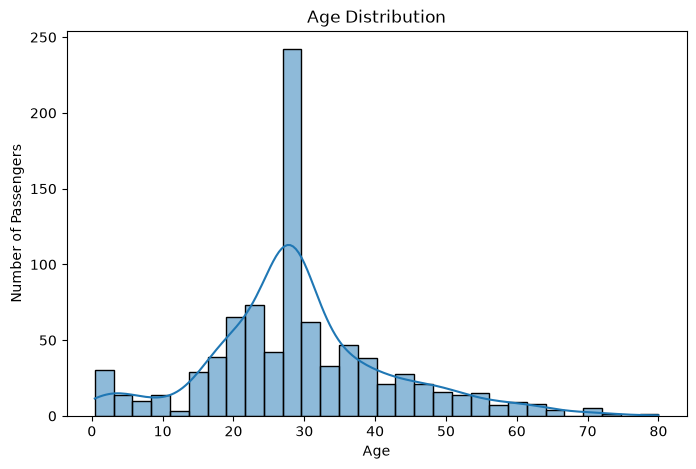

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.savefig("chart3_Age_distribution.png")
plt.show()

STAGE 4: PREPARE FOR MODELING

The target variable is:

In [23]:
y = df["Survived"]

The model features are:

In [24]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

Then the data was divided into training and testing sets:

In [25]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

The dataset was split into:

80% training data
20% testing data

STAGE 5: TRAIN A MODEL

Categorical variables such as Sex and Embarked were converted into numerical form using one-hot encoding.
Survived is a binary target variable: 0 = did not survive and 1 = survived.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical = ["Sex", "Embarked"]

numeric = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pclass','Sex','Age',...,'Embarked','FamilySize','IsAlone']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, 

STAGE 6: EVALUATE

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8044692737430168
Confusion Matrix:
[[97 13]
 [22 47]]
[[97 13]
 [22 47]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



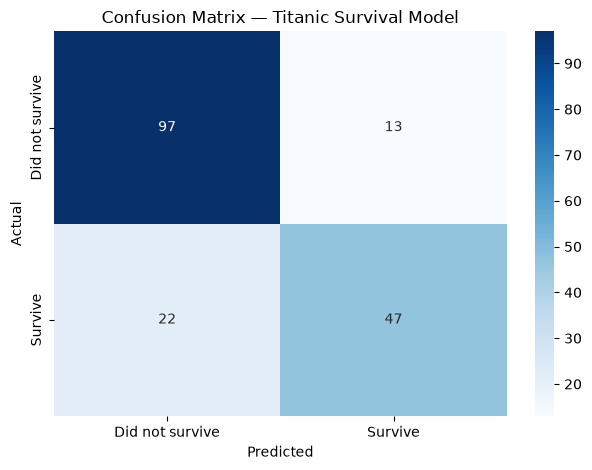

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did not survive", "Survive"],
            yticklabels=["Did not survive", "Survive"])
plt.title("Confusion Matrix — Titanic Survival Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("chart4_confusion_matrix.png")
plt.show()




This means that out of the 179 passengers in the test set:

97 passengers were correctly predicted not to survive (TN).
47 passengers were correctly predicted to survive (TP).
13 passengers were incorrectly predicted as survivors (FP).
22 survivors were incorrectly predicted as non-survivors (FN).

STAGE 7: SUMMARIZE FINDINGS

The Titanic dataset contains 891 passengers and provides information about their survival, passenger class, gender, age, family relationships, ticket, fare, cabin, and embarkation port.
After cleaning the missing data and creating additional features such as FamilySize and IsAlone, a Logistic Regression model was trained to predict survival. The model achieved approximately 80.4% accuracy,indicating that it performed reasonably well at distinguishing passengers who survived from those who did not.
The dataset suggests that passenger gender and class were strongly associated with survival, and the machine-learning model was able to use these and other passenger characteristics to predict survival with about 80% accuracy.